# Coweeta ELM+ATS Coupled Workflow

This workflow generates all input files needed for a coupled ELM+ATS simulation at the
Coweeta watershed. ELM drives all meteorological forcing and provides porosity (watsat)
to ATS at runtime via the ELM-ATS coupling layer.

Datasets used:
* `NHD Plus HR` for hydrography
* `3DEP` for elevation
* `NLCD` for land cover (PFT assignment for ELM)
* `NRCS/SSURGO` for soil texture (sand/clay → ELM pedotransfer → watsat; Rosetta → ATS WRM)

Outputs written to `elm_output_data/`:
* `coweeta_np<NTASKS>.exo` — 3D mesh (15 layers, ~42 m deep, Oak Harbor dz
  structure), partitioned into NTASKS pieces; the filename is tagged with
  NTASKS since the mesh partition is fixed at build time and must match the
  MPI rank count used to build and run the ELM+ATS cases
* `coweeta_np<NTASKS>.h5` — lat/lon cell data for ELM column matching
* `coweeta_domain.nc` — ELM domain file
* `coweeta_surfdata.nc` — ELM surface data (PFT, texture, geometry)
* `coweeta_stage1a.xml` — ATS-only steady-state spinup input (stage 1a of
  `examples/coweeta/build_example.sh`); self-contained, no ELM coupling
* `coweeta_stage2.xml`, `coweeta_stage3.xml` — ATS input files for the coupled
  ELM+ATS runs (stages 2 and 3), based on `elm_ats_template.xml`; identical except
  for which previous stage's checkpoint each restarts ATS pressure from
* `coweeta_subsurface_properties.csv` — soil properties lookup table
* `user_nl_elm_stage1b`, `user_nl_elm_stage2`, `user_nl_elm_stage3` — ELM's own
  input files for each ELM-running stage, written alongside the ATS XMLs since
  they are just as much domain-specific input generation

After running this notebook, copy the outputs into a campaign directory's shared
`inputdata/` (e.g. `Coweeta_Campaign0/inputdata/`) as described in the completion cell.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## FIX ME -- why is this broken without importing netcdf first?
import netCDF4

In [3]:
import watershed_workflow.io
watershed_workflow.io.setupLogging(1)

In [4]:
import exodus3

In [5]:
import os, sys
import logging
import numpy as np
from matplotlib import pyplot as plt
import shapely
import pandas as pd
import geopandas as gpd
pd.options.display.max_columns = None

# ats_input_spec is not pip-installable; add its source tree to the path
sys.path.insert(0, os.path.expanduser('~/code/ats/ats_input_spec/repos/master'))

import watershed_workflow
import watershed_workflow.utils
import watershed_workflow.utils.warp
import watershed_workflow.sources
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.crs
import watershed_workflow.properties.land_cover
import watershed_workflow.hydro
import watershed_workflow.io
import watershed_workflow.io.elm
import watershed_workflow.sources.standard_names as names

import ats_input_spec
import ats_input_spec.public
import ats_input_spec.io

import amanzi_xml.utils.io as aio
import amanzi_xml.utils.search as asearch
import amanzi_xml.utils.errors as aerrors

import h5py

plt.rcParams['figure.figsize'] = (8, 6)

## Parameters

In [6]:
# -----------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------
def splitPathFull(path):
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:
            parts.insert(0, head); break
        elif tail == path:
            parts.insert(0, tail); break
        else:
            parts.insert(0, tail); path = head
    return parts

cwd = splitPathFull(os.getcwd())
if cwd[-1] == 'Coweeta':
    pass
elif cwd[-1] == 'examples':
    cwd.append('Coweeta')
else:
    cwd.extend(['examples', 'Coweeta'])

data_dir = os.path.join(*(cwd + ['input_data']))
def toInput(f): return os.path.join(data_dir, f)

output_dir = os.path.join(*(cwd + ['elm_output_data']))
os.makedirs(output_dir, exist_ok=True)
def toOutput(f): return os.path.join(output_dir, f)

work_dir = os.path.join(*cwd)
def toWorkingDir(f): return os.path.join(work_dir, f)

# Point at local data cache so this notebook works offline / without large downloads
watershed_workflow.utils.setDataDirectory(data_dir)

# -----------------------------------------------------------------------
# Mesh / watershed parameters
# -----------------------------------------------------------------------
name = 'coweeta'
coweeta_shapefile = toInput('coweeta_basin.shp')

simplify          = 60
ignore_small_rivers = 2
prune_by_area_fraction = 0.01

refine_L0 = 125;  refine_L1 = 300
refine_d0 = 200;  refine_d1 = 600
refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2

# -----------------------------------------------------------------------
# ELM / ATS template paths
# -----------------------------------------------------------------------
# Oak Harbor 1-column surfdata used as template for SurfdataBuilder
template_surfdata = toInput('elm_ats_surfdata_template.nc')

# ATS XML template (site-independent ELM-ATS skeleton with MESH_FILENAME placeholders)
ats_xml_template = toInput('elm_ats_template.xml')


print(f'template_surfdata: {template_surfdata}')
print(f'ats_xml_template : {ats_xml_template}')
print(f'output_dir       : {output_dir}')

template_surfdata: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/elm_ats_surfdata_template.nc
ats_xml_template : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/elm_ats_template.xml
output_dir       : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data


In [7]:
output_filenames = {}

In [8]:
crs = watershed_workflow.crs.default_crs

## Section 1: Basin Geometry

2026-07-16 13:41:48,153 - root - INFO: fixing column: geometry
2026-07-16 13:41:48,160 - root - INFO: Removing holes on 1 polygons
2026-07-16 13:41:48,161 - root - INFO:   -- removed interior
2026-07-16 13:41:48,161 - root - INFO:   -- union
2026-07-16 13:41:48,161 - root - INFO: Parsing 1 components for holes
2026-07-16 13:41:48,162 - root - INFO:   -- complete


<Axes: >

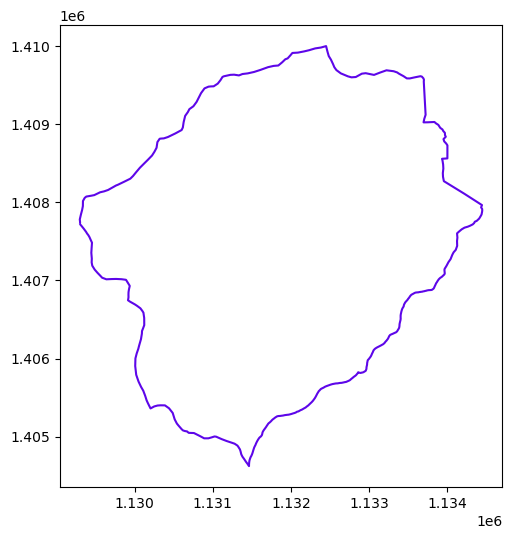

In [9]:
coweeta_source = watershed_workflow.sources.ManagerShapefile(coweeta_shapefile)
coweeta = coweeta_source.getShapes(out_crs=crs)
coweeta.rename(columns={'AREA': names.AREA}, inplace=True)
watershed = watershed_workflow.Watershed(coweeta)
watershed.plot()

In [10]:
sources = watershed_workflow.sources.getDefaultSources()
sources['hydrography'] = watershed_workflow.sources.sources['geometry']['NHDPlusHR-pynhd_nhdplushr']
watershed_workflow.sources.logSources(sources)

2026-07-16 13:41:48,289 - root - INFO: Using sources:
2026-07-16 13:41:48,290 - root - INFO: --------------
2026-07-16 13:41:48,290 - root - INFO: HUC: ManagerWBD
2026-07-16 13:41:48,290 - root - INFO: hydrography: ManagerNHD
2026-07-16 13:41:48,290 - root - INFO: DEM: Manager3DEP
2026-07-16 13:41:48,290 - root - INFO: soil structure: ManagerNRCS
2026-07-16 13:41:48,291 - root - INFO: geologic structure: ManagerGLHYMPS
2026-07-16 13:41:48,291 - root - INFO: depth to bedrock: ManagerPelletierDTB
2026-07-16 13:41:48,291 - root - INFO: land cover: ManagerNLCD
2026-07-16 13:41:48,291 - root - INFO: LAI: ManagerMODISEarthdata
2026-07-16 13:41:48,291 - root - INFO: meteorology: ManagerAORC
2026-07-16 13:41:48,291 - root - INFO: evapotranspiration: ManagerSSEBop
2026-07-16 13:41:48,292 - root - INFO: observations: ManagerNWIS


In [11]:
reaches = sources['hydrography'].getShapesByGeometry(watershed.exterior, crs, out_crs=crs)
rivers  = watershed_workflow.hydro.createRivers(reaches, method='hydroseq')
watershed_orig, rivers_orig = watershed, rivers

2026-07-16 13:41:48,315 - root - INFO:   Shapes manager: buffered+snapped query box = (-83.482, 35.024, -83.418, 35.077)
2026-07-16 13:41:49,222 - root - INFO: fixing column: geometry
2026-07-16 13:41:49,242 - root - INFO: fixing column: catchment


In [12]:
def createCopy(ws, rivs):
    return ws.deepcopy(), [r.deepcopy() for r in rivs]

watershed, rivers = createCopy(watershed_orig, rivers_orig)

watershed_workflow.simplify(watershed, rivers, refine_L0, refine_L1, refine_d0, refine_d1)
for river in rivers:
    river.resetDataFrame()
for river in rivers:
    watershed_workflow.hydro.findOutletsByCrossings(watershed, river)

2026-07-16 13:41:49,272 - root - INFO: 
2026-07-16 13:41:49,272 - root - INFO: Simplifying
2026-07-16 13:41:49,273 - root - INFO: ------------------------------
2026-07-16 13:41:49,273 - root - INFO: EPSG:5070
2026-07-16 13:41:49,273 - root - INFO: Presimplify to remove colinear, coincident points.
2026-07-16 13:41:49,275 - root - INFO: EPSG:5070
2026-07-16 13:41:49,276 - root - INFO: Pruning leaf reaches < 125
2026-07-16 13:41:49,276 - root - INFO: EPSG:5070
2026-07-16 13:41:49,276 - root - INFO: Merging internal reaches < 125
2026-07-16 13:41:49,277 - root - INFO: EPSG:5070
2026-07-16 13:41:49,279 - root - INFO:   reach: min seg length: 	    4.7213180357 	min geom length: 	  165.1231825930
2026-07-16 13:41:49,279 - root - INFO:   reach: med seg length: 	    5.7469025712 	med geom length: 	  987.4061283577
2026-07-16 13:41:49,279 - root - INFO:   reach: max seg length: 	   28.5938776314 	max geom length: 	 4068.7144554581
2026-07-16 13:41:49,279 - root - INFO: 
2026-07-16 13:41:49,280

2026-07-16 13:41:49,506 - root - INFO: 
2026-07-16 13:41:49,507 - root - INFO: Stream-aligned Meshing
2026-07-16 13:41:49,508 - root - INFO: ------------------------------
2026-07-16 13:41:49,508 - root - INFO: Creating stream-aligned mesh...
2026-07-16 13:41:49,539 - root - INFO:  ... created a mesh with 190 elements for river 0
2026-07-16 13:41:49,539 - root - INFO: Adjusting HUC to match reaches at outlet
2026-07-16 13:41:49,547 - root - INFO:   is nonoverlapping?  total_area = 205801.2474072762, summed_area = 205801.2474072762
2026-07-16 13:41:49,548 - root - INFO: Building the remaining triangular mesh...
2026-07-16 13:41:49,548 - root - INFO: 
2026-07-16 13:41:49,548 - root - INFO: Triangulation
2026-07-16 13:41:49,548 - root - INFO: ------------------------------
2026-07-16 13:41:49,608 - root - INFO: Triangulating...
2026-07-16 13:41:49,609 - root - INFO:    455 points and 456 facets
2026-07-16 13:41:49,609 - root - INFO:  checking graph consistency
2026-07-16 13:41:49,609 - ro

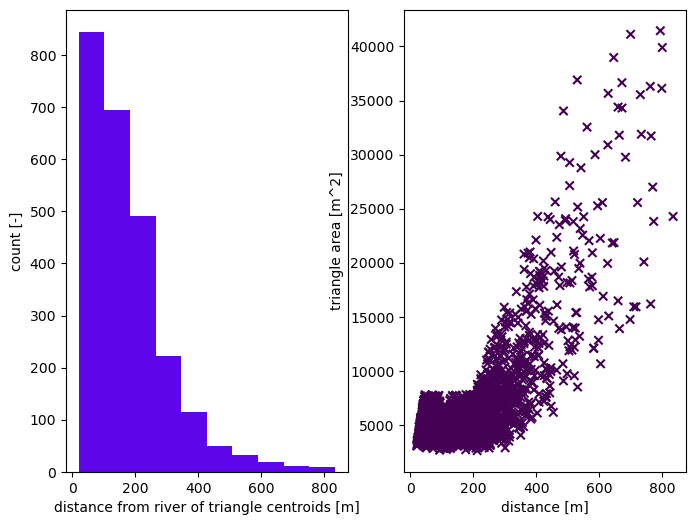

In [13]:
min_angle = 32

def widths(reach):
    mapping = {1: 8, 2: 12, 3: 16}
    return mapping.get(reach.properties['stream_order'], 8)

m2, areas, dists = watershed_workflow.tessalateRiverAligned(
    watershed, rivers,
    river_width=widths,
    refine_min_angle=min_angle,
    refine_distance=[refine_d0, refine_A0, refine_d1, refine_A1],
    diagnostics=True)

In [14]:
# elevate to a dem
dem = sources['DEM'].getDataset(watershed.exterior.buffer(100), watershed.crs)['dem']
watershed_workflow.elevate(m2, dem)

2026-07-16 13:41:55,977 - root - INFO: Incoming shape area = 0.001768840316859954
2026-07-16 13:41:55,978 - root - INFO: ... buffering incoming shape by 3x native resolution = 0.00324
2026-07-16 13:41:55,978 - root - INFO: ... buffered shape area = 0.0023523275716883477
2026-07-16 13:41:55,978 - root - INFO: Manager3DEP: cache hit at /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/elevation/3DEP_60m/py3dep_tnm/py3dep_tnm_-83.4829_35.0233_-83.4170_35.0784


In [15]:
# now deal with the river...
# adding elevations to the river tree for stream bed conditioning
watershed_workflow.mesh.setProfileByDEM(rivers, dem)

In [16]:
# now condition the river to fix places where the DEM does not intersect the river
def computeBurnInDepthFromData(reach):
    return reach['bankfull_depth'] 

def computeBurnInDepth(da_sq_miles):
    """burn-in depth as a function of drainage area"""
    depth_in_feet = 1.22 * da_sq_miles**0.317
    return 0.3048 * depth_in_feet # ft --> meters

def computeBurnInDepthFromDA(reach):
    depth = computeBurnInDepth(reach['drainage_area_sqkm'] * 0.386102)
    logging.debug(f"reach of DA {reach['drainage_area_sqkm']} has depth {depth}")
    return depth

watershed_workflow.mesh.conditionRiverMeshes(m2,
                       rivers,
                       network_burn_in_depth=computeBurnInDepthFromDA)

In [17]:
# hydrologically condition the mesh, removing pits
outlet_edge = watershed_workflow.mesh.Edge(rivers[0]['elems'][-1][0],rivers[0]['elems'][-1][-1])
print(outlet_edge)
river_cells = [i for (i,elem) in enumerate(m2.conn) if len(elem) > 3]    
m2, res = watershed_workflow.mesh.conditionMesh(m2, preserved_pits=river_cells, forced_outlet_edges=[outlet_edge,])

2026-07-16 13:41:56,166 - root - INFO: 
2026-07-16 13:41:56,166 - root - INFO: Running marching_iterative: 6 initial pits
2026-07-16 13:41:56,166 - root - INFO: ==============================================================================
2026-07-16 13:41:56,323 - root - INFO:  ... iteration 0 of marching: 1 pits


Edge(0, 380)


2026-07-16 13:41:56,483 - root - INFO:  ... iteration 1 of marching: 1 pits
2026-07-16 13:41:56,639 - root - INFO:  ... iteration 2 of marching: 1 pits
2026-07-16 13:41:56,640 - root - INFO:  ... done iterating, max iterations.
2026-07-16 13:41:56,673 - root - INFO:   completed: 1 final pits, 5 removed
2026-07-16 13:41:56,674 - root - INFO:     - 1 'internal' pits with max depth 5.436848958333485 and median 5.436848958333485
2026-07-16 13:41:56,674 - root - INFO:   RMSE of dz: 0.10463231238752121
2026-07-16 13:41:56,674 - root - INFO:   MAE of dz: 0.0045790376772588326
2026-07-16 13:41:56,674 - root - INFO:   MAX of dz: 3.13311767578125
2026-07-16 13:41:56,675 - root - INFO: Refining 1 triangles -- topology will change!
2026-07-16 13:41:56,725 - root - INFO: 
2026-07-16 13:41:56,725 - root - INFO: Running marching_iterative: 1 initial pits
2026-07-16 13:41:56,726 - root - INFO: ==============================================================================
2026-07-16 13:41:56,882 - root

In [18]:
print(m2.cell_areas[0])

5573.98080026525


In [19]:
# pre-partition
# NTASKS must match the MPI rank count build_example.sh will use to build and
# run the ELM+ATS cases -- ATS's mesh decomposition (and any checkpoint
# restart across spinup stages) is fixed at this partition count. The mesh
# filename itself is tagged with NTASKS (mesh_name, used below for
# coweeta_np<NTASKS>.exo / coweeta_np<NTASKS>.h5) so a stale mesh built for a
# different task count is obviously
# named wrong rather than silently mismatched -- build_example.sh's own
# NTASKS-vs-partition-count check is a second, independent guard on the same
# invariant.
try:
    ntasks = int(os.environ['NTASKS'])
except KeyError:
    ntasks = 4 # default for Coweeta
mesh_name = f'{name}_np{ntasks}'
m2 = m2.partition(ntasks, True)

In [20]:
print(m2.cell_areas[0])
print(m2.centroids[0])

4029.9606990153047
[1.13250097e+06 1.40887104e+06 7.49100952e+02]


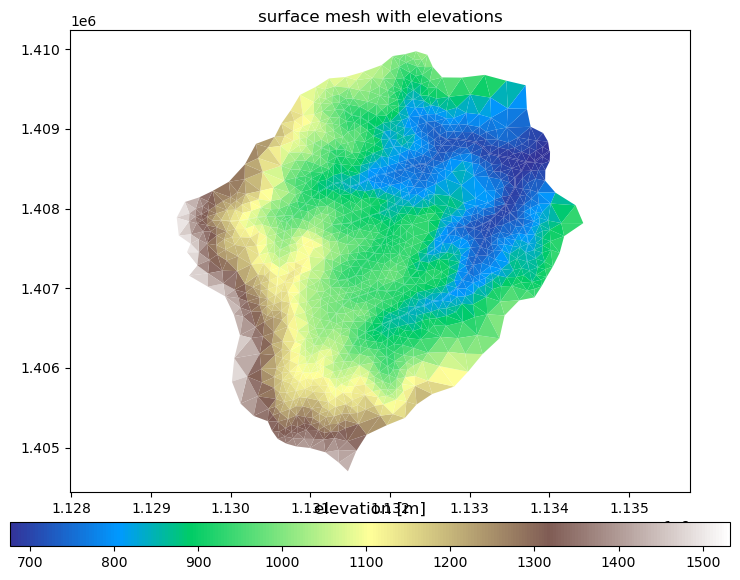

In [21]:
fig, ax = plt.subplots()
cbax = fig.add_axes([0.05, 0.02, 0.9, 0.04])
mp = m2.plot(facecolors='elevation', edgecolors=None, ax=ax, colorbar=False)
fig.colorbar(mp, orientation='horizontal', cax=cbax).ax.set_title('elevation [m]')
ax.set_title('surface mesh with elevations')
ax.set_aspect('equal', 'datalim')
plt.show()

In [22]:
watershed_workflow.mesh.addWatershedAndOutletRegions(m2, watershed, outlet_width=250, exterior_outlet=True)
watershed_workflow.mesh.addRiverCorridorRegions(m2, rivers)
watershed_workflow.mesh.addStreamOrderRegions(m2, rivers)

for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

2026-07-16 13:41:57,280 - root - INFO: Adding regions for 1 polygons
2026-07-16 13:41:57,360 - root - INFO: Exterior outlet point (from attribute): POINT (1134002.8976153187 1408719.2929211305)


10000 : CELL : 2701 : "0"
10001 : CELL : 2701 : "0 surface"
10002 : FACE : 76 : "0 boundary"
10003 : FACE : 5 : "0 outlet"
10004 : FACE : 5 : "surface domain outlet"
10005 : CELL : 190 : "river corridor 0 surface"
10006 : CELL : 16 : "stream order 3"
10007 : CELL : 48 : "stream order 2"
10008 : CELL : 126 : "stream order 1"


In [23]:
print(m2.num_cells)

2701


## Section 2: NLCD Land Cover and ELM PFT Assignment

In [24]:
nlcd = sources['land cover'].getDataset(watershed.exterior.buffer(100), watershed.crs)['cover']
logging.info('Found land cover types: {}'.format(set(list(nlcd.values.ravel()))))

2026-07-16 13:41:57,415 - root - INFO: Incoming shape area = 0.001768840316859954
2026-07-16 13:41:57,415 - root - INFO: ... buffering incoming shape by 3x native resolution = 0.00081
2026-07-16 13:41:57,415 - root - INFO: ... buffered shape area = 0.001909149726363946
2026-07-16 13:41:57,416 - root - INFO: ManagerNLCD: cache hit at /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/input_data/land_cover/NLCD_L48_2021/pygeohydro_mrlc/pygeohydro_mrlc_-83.4800_35.0263_-83.4200_35.0754
2026-07-16 13:41:57,424 - root - INFO: Found land cover types: {np.int16(71), np.int16(41), np.int16(42), np.int16(43), np.int16(81), np.int16(52), np.int16(21), np.int16(22), np.int16(23), np.int16(-1)}


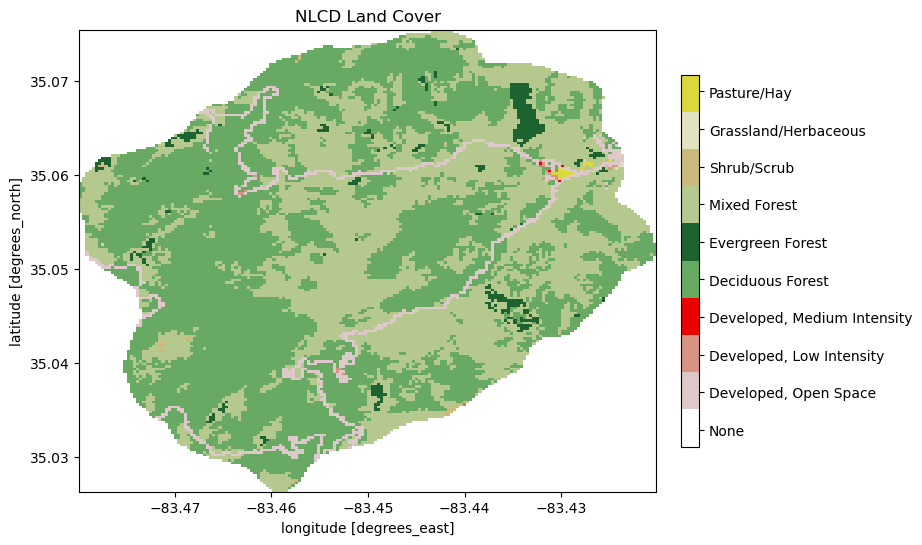

In [25]:
nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
    watershed_workflow.plot.createNLCDColormap(np.unique(nlcd))

fig, ax = plt.subplots()
nlcd.plot.imshow(ax=ax, cmap=nlcd_cmap, norm=nlcd_norm, add_colorbar=False)
watershed_workflow.plot.createIndexedColorbar(
    ncolors=len(nlcd_indices), cmap=nlcd_cmap, labels=nlcd_labels, ax=ax)
ax.set_title('NLCD Land Cover')
plt.show()

In [26]:
m2_nlcd = watershed_workflow.getDatasetOnMesh(m2, nlcd, method='nearest')
m2.cell_data['land_cover'] = m2_nlcd

assert 127 not in m2_nlcd, 'nodata NLCD value found on mesh'

nlcd_indices, nlcd_cmap, nlcd_norm, nlcd_ticks, nlcd_labels = \
    watershed_workflow.plot.createNLCDColormap(np.unique(m2_nlcd))

In [27]:
# Map NLCD codes to ELM natural PFT indices (0-16)
pft_index = watershed_workflow.properties.land_cover.mapNLCDToPFT(
    m2_nlcd, climate_zone='temperate')
m2.cell_data['pft index'] = pft_index

print('PFT indices on mesh:', np.unique(pft_index))

PFT indices on mesh: [ 1  7 13]


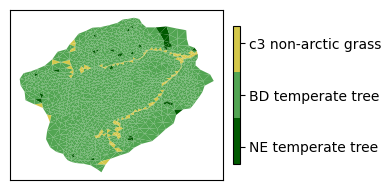

In [28]:
fig, ax = plt.subplots(1,1, figsize=(4,2))
pft_index_list, pft_cmap, pft_norm, pft_ticks, pft_labels = \
    watershed_workflow.plot.createPFTColormap(np.unique(pft_index))

mp = m2.plot('pft index', cmap=pft_cmap, norm=pft_norm,
             edgecolors=None, colorbar=False, ax=ax)
watershed_workflow.plot.createIndexedColorbar(
    ncolors=len(pft_index_list), cmap=pft_cmap, labels=pft_labels, ax=plt.gca())
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()

fig.savefig('./Coweeta_PFTs.png', dpi=300)

plt.show()

In [29]:
nlcd_labels_dict = dict(zip(nlcd_indices, nlcd_labels))
watershed_workflow.mesh.addSurfaceRegions(m2, names=nlcd_labels_dict)

for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

10000 : CELL : 2701 : "0"
10001 : CELL : 2701 : "0 surface"
10002 : FACE : 76 : "0 boundary"
10003 : FACE : 5 : "0 outlet"
10004 : FACE : 5 : "surface domain outlet"
10005 : CELL : 190 : "river corridor 0 surface"
10006 : CELL : 16 : "stream order 3"
10007 : CELL : 48 : "stream order 2"
10008 : CELL : 126 : "stream order 1"
21 : CELL : 121 : "Developed, Open Space"
22 : CELL : 4 : "Developed, Low Intensity"
41 : CELL : 1398 : "Deciduous Forest"
42 : CELL : 38 : "Evergreen Forest"
43 : CELL : 1134 : "Mixed Forest"
81 : CELL : 6 : "Pasture/Hay"


## Section 3: NRCS Soil Texture and ATS WRM Parameters

NRCS SSURGO provides sand/clay texture used for:
- ELM: pedotransfer function `watsat = 0.489 - 0.00126*sand` (all 15 nlevgrnd layers)
- ATS: Rosetta van Genuchten parameters (alpha, n, residual saturation) and permeability

Each column is vertically homogeneous — the same NRCS MUKEY texture applies to all 15
layers.  ELM internally duplicates layer-10 texture for layers 11-15 (SoilStateType.F90
lines 708-713), consistent with this approach.

In [30]:
nrcs = sources['soil structure'].getShapesByGeometry(
    watershed.exterior, watershed.crs, out_crs=crs)
nrcs

2026-07-16 13:41:57,680 - root - INFO:   Shapes manager: buffered+snapped query box = (-83.48100000000001, 35.025, -83.419, 35.077)
2026-07-16 13:41:57,687 - root - INFO: fixing column: geometry


,mukey,residual saturation [-],Rosetta porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],Rosetta permeability [m^2],thickness [m],permeability [m^2],porosity [-],bulk density [g/cm^3],total sand pct [%],total silt pct [%],total clay pct [%],source,geometry,ID,name
0,545800,0.177165,0.431041,0.000139,1.470755,8.079687e-13,2.03,3.429028e-15,0.307246,1.297356,66.356250,19.518750,14.125000,NRCS,"MULTIPOLYGON (((1131428.197 1404429.105, 11314...",545800,NRCS-545800
1,545801,0.177493,0.432741,0.000139,1.469513,8.184952e-13,2.03,3.247236e-15,0.303714,1.292308,66.400000,19.300000,14.300000,NRCS,"MULTIPOLYGON (((1129506.994 1406944.207, 11294...",545801,NRCS-545801
2,545803,0.172412,0.400889,0.000150,1.491087,6.477202e-13,2.03,2.800000e-12,0.379163,1.400000,66.799507,21.700493,11.500000,NRCS,"MULTIPOLYGON (((1130760.995 1408224.107, 11307...",545803,NRCS-545803
3,545805,0.177122,0.388687,0.000083,1.468789,3.412748e-13,2.03,2.800000e-12,0.384877,1.400000,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1134365.598 1404976.304, 11343...",545805,NRCS-545805
4,545806,0.177122,0.388687,0.000083,1.468789,3.412748e-13,2.03,2.800000e-12,0.384877,1.400000,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1134266.398 1405134.104, 11342...",545806,NRCS-545806
5,545807,0.177122,0.388687,0.000083,1.468789,3.412748e-13,2.03,2.800000e-12,0.384877,1.400000,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1131255.496 1405664.406, 11312...",545807,NRCS-545807
6,545811,0.185732,0.387543,0.000162,1.466606,4.631920e-13,2.03,1.196738e-12,0.330802,1.484203,68.011736,18.128229,13.860034,NRCS,"MULTIPOLYGON (((1129735.028 1404130.239, 11297...",545811,NRCS-545811
8,545813,0.183468,0.398767,0.000127,1.445858,4.296896e-13,2.03,6.219065e-14,0.349442,1.410667,60.007287,26.226047,13.766667,NRCS,"MULTIPOLYGON (((1130154.996 1404344.106, 11301...",545813,NRCS-545813
9,545814,0.183709,0.398135,0.000126,1.444985,4.224967e-13,2.03,5.999907e-14,0.344322,1.412931,59.790685,26.427142,13.782173,NRCS,"MULTIPOLYGON (((1131341.197 1404436.605, 11313...",545814,NRCS-545814
10,545815,0.178116,0.409712,0.000161,1.496402,7.229891e-13,2.03,4.813863e-14,0.314865,1.392630,70.125671,16.487364,13.386966,NRCS,"MULTIPOLYGON (((1130279.896 1404358.006, 11302...",545815,NRCS-545815


In [31]:
print(watershed_workflow.properties.soil.__file__)

/Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/watershed_workflow/properties/soil.py


In [32]:
def replaceColumnNans(df, col_nan, col_replacement):
    mask = df[col_nan].isna()
    df.loc[mask, col_nan] = df.loc[mask, col_replacement]

# Fill any missing Rosetta-derived values with Rosetta fallback columns
replaceColumnNans(nrcs, 'porosity [-]', 'Rosetta porosity [-]')
replaceColumnNans(nrcs, 'permeability [m^2]', 'Rosetta permeability [m^2]')

# Drop Rosetta backup columns (we keep the originals, now gap-filled)
for col in ['Rosetta porosity [-]', 'Rosetta permeability [m^2]',
            'bulk density [g/cm^3]']:
    if col in nrcs.columns:
        nrcs.pop(col)

# Drop any rows still containing NaN
nan_mask = nrcs.isna().any(axis=1)
dropped = nrcs.index[nan_mask]
if len(dropped):
    logging.warning(f'Dropping {len(dropped)} NRCS rows with NaN after gap-fill: {list(dropped)}')
nrcs = nrcs[~nan_mask]

nrcs

,mukey,residual saturation [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],thickness [m],permeability [m^2],porosity [-],total sand pct [%],total silt pct [%],total clay pct [%],source,geometry,ID,name
0,545800,0.177165,0.000139,1.470755,2.03,3.429028e-15,0.307246,66.356250,19.518750,14.125000,NRCS,"MULTIPOLYGON (((1131428.197 1404429.105, 11314...",545800,NRCS-545800
1,545801,0.177493,0.000139,1.469513,2.03,3.247236e-15,0.303714,66.400000,19.300000,14.300000,NRCS,"MULTIPOLYGON (((1129506.994 1406944.207, 11294...",545801,NRCS-545801
2,545803,0.172412,0.000150,1.491087,2.03,2.800000e-12,0.379163,66.799507,21.700493,11.500000,NRCS,"MULTIPOLYGON (((1130760.995 1408224.107, 11307...",545803,NRCS-545803
3,545805,0.177122,0.000083,1.468789,2.03,2.800000e-12,0.384877,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1134365.598 1404976.304, 11343...",545805,NRCS-545805
4,545806,0.177122,0.000083,1.468789,2.03,2.800000e-12,0.384877,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1134266.398 1405134.104, 11342...",545806,NRCS-545806
5,545807,0.177122,0.000083,1.468789,2.03,2.800000e-12,0.384877,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1131255.496 1405664.406, 11312...",545807,NRCS-545807
6,545811,0.185732,0.000162,1.466606,2.03,1.196738e-12,0.330802,68.011736,18.128229,13.860034,NRCS,"MULTIPOLYGON (((1129735.028 1404130.239, 11297...",545811,NRCS-545811
8,545813,0.183468,0.000127,1.445858,2.03,6.219065e-14,0.349442,60.007287,26.226047,13.766667,NRCS,"MULTIPOLYGON (((1130154.996 1404344.106, 11301...",545813,NRCS-545813
9,545814,0.183709,0.000126,1.444985,2.03,5.999907e-14,0.344322,59.790685,26.427142,13.782173,NRCS,"MULTIPOLYGON (((1131341.197 1404436.605, 11313...",545814,NRCS-545814
10,545815,0.178116,0.000161,1.496402,2.03,4.813863e-14,0.314865,70.125671,16.487364,13.386966,NRCS,"MULTIPOLYGON (((1130279.896 1404358.006, 11302...",545815,NRCS-545815


In [33]:
# Map NRCS MUKEY onto the 2D mesh cells
soil_color_mukey = watershed_workflow.getShapePropertiesOnMesh(
    m2, nrcs, 'mukey', resolution=50, nodata=-999)

# Fail if any mesh cell has no NRCS coverage
assert -999 not in soil_color_mukey, \
    'Some mesh cells have no NRCS coverage (nodata=-999). Check watershed extent vs SSURGO.'

nrcs.set_index('mukey', drop=False, inplace=True)

unique_mukeys = list(np.unique(soil_color_mukey))
nrcs = nrcs.loc[unique_mukeys]  # keep only MUKEYs that appear on the mesh

# Assign sequential ATS IDs starting at 1000
nrcs['ATS ID'] = range(1000, 1000 + len(unique_mukeys))
nrcs.set_index('ATS ID', drop=True, inplace=True)

# Build the ATS-ID indexed soil color array
soil_color = -np.ones_like(soil_color_mukey)
for ats_id, mukey in zip(nrcs.index, nrcs['mukey']):
    soil_color[soil_color_mukey == mukey] = ats_id

m2.cell_data['soil_color'] = soil_color
print(f'{len(nrcs)} unique NRCS soil types on mesh, ATS IDs {nrcs.index.min()}–{nrcs.index.max()}')

33 unique NRCS soil types on mesh, ATS IDs 1000–1032


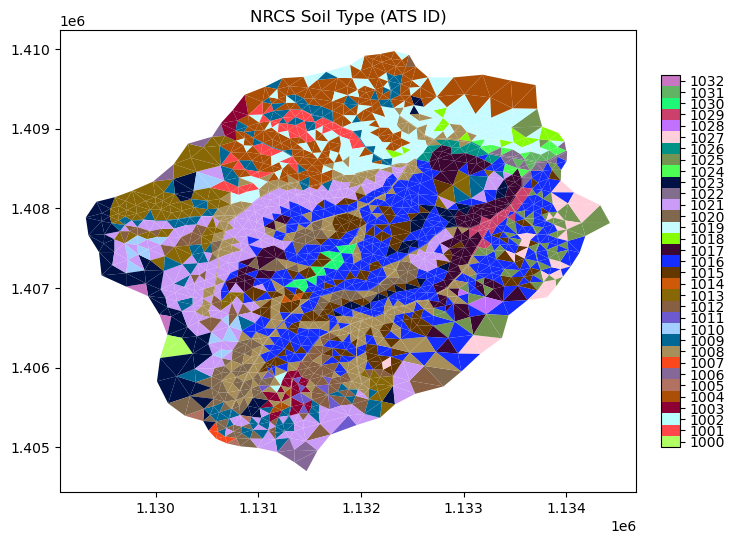

In [34]:
sc_indices, sc_cmap, sc_norm, sc_ticks, sc_labels = \
    watershed_workflow.plot.createIndexedColormap(nrcs.index)

mp = m2.plot(facecolors=m2.cell_data['soil_color'], cmap=sc_cmap, norm=sc_norm,
             edgecolors=None, colorbar=False)
watershed_workflow.plot.createIndexedColorbar(
    ncolors=len(nrcs), cmap=sc_cmap, labels=sc_labels, ax=plt.gca())
plt.title('NRCS Soil Type (ATS ID)')
plt.show()

In [35]:
# Save subsurface properties CSV
output_filenames['subsurface_properties'] = toOutput(f'{name}_subsurface_properties.csv')
nrcs.to_csv(output_filenames['subsurface_properties'])
print('Saved:', output_filenames['subsurface_properties'])
nrcs

Saved: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_subsurface_properties.csv


,mukey,residual saturation [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],thickness [m],permeability [m^2],porosity [-],total sand pct [%],total silt pct [%],total clay pct [%],source,geometry,ID,name
ATS ID,,,,,,,,,,,,,,
1000,545800,0.177165,0.000139,1.470755,2.03,3.429028e-15,0.307246,66.356250,19.518750,14.125000,NRCS,"MULTIPOLYGON (((1131428.197 1404429.105, 11314...",545800,NRCS-545800
1001,545803,0.172412,0.000150,1.491087,2.03,2.800000e-12,0.379163,66.799507,21.700493,11.500000,NRCS,"MULTIPOLYGON (((1130760.995 1408224.107, 11307...",545803,NRCS-545803
1002,545805,0.177122,0.000083,1.468789,2.03,2.800000e-12,0.384877,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1134365.598 1404976.304, 11343...",545805,NRCS-545805
1003,545806,0.177122,0.000083,1.468789,2.03,2.800000e-12,0.384877,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1134266.398 1405134.104, 11342...",545806,NRCS-545806
1004,545807,0.177122,0.000083,1.468789,2.03,2.800000e-12,0.384877,46.721675,41.778325,11.500000,NRCS,"MULTIPOLYGON (((1131255.496 1405664.406, 11312...",545807,NRCS-545807
1005,545813,0.183468,0.000127,1.445858,2.03,6.219065e-14,0.349442,60.007287,26.226047,13.766667,NRCS,"MULTIPOLYGON (((1130154.996 1404344.106, 11301...",545813,NRCS-545813
1006,545814,0.183709,0.000126,1.444985,2.03,5.999907e-14,0.344322,59.790685,26.427142,13.782173,NRCS,"MULTIPOLYGON (((1131341.197 1404436.605, 11313...",545814,NRCS-545814
1007,545815,0.178116,0.000161,1.496402,2.03,4.813863e-14,0.314865,70.125671,16.487364,13.386966,NRCS,"MULTIPOLYGON (((1130279.896 1404358.006, 11302...",545815,NRCS-545815
1008,545818,0.177633,0.000153,1.480849,2.03,2.912604e-12,0.305511,70.847537,13.736515,15.415948,NRCS,"MULTIPOLYGON (((1129923.796 1404321.806, 11299...",545818,NRCS-545818


## Section 4: Extrude 2D Mesh to 3D

Uses ELM's default exponential 15-layer vertical grid (`elm_default_dzsoi`, ~42 m total depth).
All 15 layers get the same NRCS soil type as the surface cell (vertically homogeneous).
Mat IDs 1000–(1000+N) for ELM nlevsoi layers; same IDs continue for layers 11-15 since
ELM duplicates layer-10 texture internally.

In [36]:
# ELM vertical grid -- uses ELM's default exponential formula (initVerticalMod.F90)
dzs = watershed_workflow.io.elm.elm_default_dzsoi(nlevgrnd=15)

print(f'Number of layers: {len(dzs)}')
print(f'Layer thicknesses: {np.round(dzs, 4)}')
print(f'Total depth: {dzs.sum():.2f} m')


Number of layers: 15
Layer thicknesses: [ 0.0175  0.0276  0.0455  0.075   0.1236  0.2038  0.336   0.5539  0.9133
  1.5058  2.4826  4.0931  6.7484 11.1262 13.8512]
Total depth: 42.10 m


In [37]:
ncells = m2.num_cells
soil_color_arr = m2.cell_data['soil_color'].values  # shape (ncells,), ATS IDs

# All 15 layers get the surface cell's NRCS ATS ID (vertically homogeneous)
layer_mat_ids = [soil_color_arr.copy() for _ in range(15)]

watershed_workflow.Mesh3D.summarizeExtrusion(
    ['constant'] * 15, dzs.tolist(), [1] * 15, layer_mat_ids)

2026-07-16 13:41:58,068 - root - INFO: Cell summary:
2026-07-16 13:41:58,068 - root - INFO: ------------------------------------------------------------
2026-07-16 13:41:58,068 - root - INFO: l_id	| c_id	|mat_id	| dz		| z_top
2026-07-16 13:41:58,068 - root - INFO: ------------------------------------------------------------
2026-07-16 13:41:58,068 - root - INFO:  00 	| 00 	| 1019 	|   0.017513 	|   0.000000
2026-07-16 13:41:58,069 - root - INFO:  01 	| 01 	| 1019 	|   0.027579 	|   0.017513
2026-07-16 13:41:58,069 - root - INFO:  02 	| 02 	| 1019 	|   0.045470 	|   0.045092
2026-07-16 13:41:58,069 - root - INFO:  03 	| 03 	| 1019 	|   0.074967 	|   0.090562
2026-07-16 13:41:58,069 - root - INFO:  04 	| 04 	| 1019 	|   0.123600 	|   0.165529
2026-07-16 13:41:58,069 - root - INFO:  05 	| 05 	| 1019 	|   0.203783 	|   0.289130
2026-07-16 13:41:58,069 - root - INFO:  06 	| 06 	| 1019 	|   0.335981 	|   0.492912
2026-07-16 13:41:58,069 - root - INFO:  07 	| 07 	| 1019 	|   0.553938 	|   0.8

In [38]:
m3 = watershed_workflow.Mesh3D.extruded_Mesh2D(
    m2, 'constant', dzs.tolist(), [1] * 15, layer_mat_ids)

In [39]:
print('2D labeled sets')
for ls in m2.labeled_sets:
    print(f'  {ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('\n3D labeled sets')
for ls in m3.labeled_sets:
    print(f'  {ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('\n3D side sets')
for ss in m3.side_sets:
    print(f'  {ss.setid} : FACE : {len(ss.cell_list)} : "{ss.name}"')

2D labeled sets
  10000 : CELL : 2701 : "0"
  10001 : CELL : 2701 : "0 surface"
  10002 : FACE : 76 : "0 boundary"
  10003 : FACE : 5 : "0 outlet"
  10004 : FACE : 5 : "surface domain outlet"
  10005 : CELL : 190 : "river corridor 0 surface"
  10006 : CELL : 16 : "stream order 3"
  10007 : CELL : 48 : "stream order 2"
  10008 : CELL : 126 : "stream order 1"
  21 : CELL : 121 : "Developed, Open Space"
  22 : CELL : 4 : "Developed, Low Intensity"
  41 : CELL : 1398 : "Deciduous Forest"
  42 : CELL : 38 : "Evergreen Forest"
  43 : CELL : 1134 : "Mixed Forest"
  81 : CELL : 6 : "Pasture/Hay"

3D labeled sets
  10000 : CELL : 40515 : "0"

3D side sets
  1 : FACE : 2701 : "bottom"
  2 : FACE : 2701 : "surface"
  3 : FACE : 1140 : "external sides"
  10001 : FACE : 2701 : "0 surface"
  10002 : FACE : 1140 : "0 boundary"
  10003 : FACE : 75 : "0 outlet"
  10004 : FACE : 75 : "surface domain outlet"
  10005 : FACE : 190 : "river corridor 0 surface"
  10006 : FACE : 16 : "stream order 3"
  10007 

In [40]:
# Partition the 2D mesh and write lat/lon cell data for ELM column matching
centroids = m2.centroids[:, 0:2]
lon, lat = watershed_workflow.utils.warp.warpXY(
    centroids[:, 0], centroids[:, 1], m2.crs, watershed_workflow.crs.latlon_crs)

m2.cell_data['longitude'] = lon
m2.cell_data['latitude']  = lat

output_filenames['mesh_h5'] = toOutput(f'{mesh_name}.h5')

# should put this capability somewhere in the library, but its specific to both ATS and HDF?
with h5py.File(output_filenames['mesh_h5'], 'w') as fid:
    grp1 = fid.create_group('longitude.cell.0')
    grp1.create_dataset('0', data=lon)

    grp2 = fid.create_group('latitude.cell.0')
    grp2.create_dataset('0', data=lat)

print('Wrote:', output_filenames['mesh_h5'])

Wrote: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_np4.h5


In [41]:
# Write 3D mesh exodus file
output_filenames['mesh'] = toOutput(f'{mesh_name}.exo')
try:
    os.remove(output_filenames['mesh'])
except FileNotFoundError:
    pass
m3.writeExodus(output_filenames['mesh'], 'one block')
print('Wrote:', output_filenames['mesh'])

2026-07-16 13:41:58,381 - root - INFO: writing partition data as variable
2026-07-16 13:41:58,386 - root - INFO: adding side set: 1
2026-07-16 13:41:58,391 - root - INFO: adding side set: 2
2026-07-16 13:41:58,396 - root - INFO: adding side set: 3
2026-07-16 13:41:58,398 - root - INFO: adding side set: 10001
2026-07-16 13:41:58,400 - root - INFO: adding side set: 10002
2026-07-16 13:41:58,401 - root - INFO: adding side set: 10003
2026-07-16 13:41:58,402 - root - INFO: adding side set: 10004
2026-07-16 13:41:58,403 - root - INFO: adding side set: 10005
2026-07-16 13:41:58,405 - root - INFO: adding side set: 10006
2026-07-16 13:41:58,406 - root - INFO: adding side set: 10007
2026-07-16 13:41:58,407 - root - INFO: adding side set: 10008
2026-07-16 13:41:58,408 - root - INFO: adding side set: 21
2026-07-16 13:41:58,409 - root - INFO: adding side set: 22
2026-07-16 13:41:58,410 - root - INFO: adding side set: 41
2026-07-16 13:41:58,413 - root - INFO: adding side set: 42
2026-07-16 13:41:58,


You are using exodus.py v 1.21.6 (seacas-py3), a python wrapper of some of the exodus library.

Copyright (c) 2013-2023 National Technology &
Engineering Solutions of Sandia, LLC (NTESS).  Under the terms of
Contract DE-NA0003525 with NTESS, the U.S. Government retains certain
rights in this software.

Opening exodus file: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_np4.exo
Closing exodus file: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_np4.exo
Wrote: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_np4.exo


## Section 5: ELM Domain and Surface Data Files

- `writeDomain()` writes the ELM domain NetCDF (lat/lon/area/mask/frac per cell)
- `SurfdataBuilder` clones the Oak Harbor template surfdata, replaces geometry and land
  cover, then fills soil texture from NRCS sand/clay for the 10 ELM `nlevsoi` layers.
  ELM internally duplicates layer-10 texture for layers 11-15 (SoilStateType.F90 708-713).

These files are shared across every ELM run in the spinup workflow (stages 1b, 2, and 3
in `examples/coweeta/build_example.sh`) -- they are built once here, from the same mesh
and NRCS data used throughout this notebook, so they always match the ATS mesh exactly.
Stage 1b in particular reuses `coweeta_domain.nc` / `coweeta_surfdata.nc`
as-is; nothing further needs to be generated for it.

In [42]:
output_filenames['elm_domain'] = toOutput(f'{name}_domain.nc')
watershed_workflow.io.elm.writeDomain(m2, output_filenames['elm_domain'])
print('Wrote ELM domain:', output_filenames['elm_domain'])

Wrote ELM domain: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_domain.nc


In [43]:
# Build the SurfdataBuilder (requires 'pft index' in m2.cell_data)
builder = watershed_workflow.io.elm.SurfdataBuilder(m2, template_surfdata)
nlevsoi = builder._nlevsoi  # should be 10
print(f'Template nlevsoi: {nlevsoi}')

Template nlevsoi: 10


In [44]:
# Build soil_type array: shape (nlevsoi=10, ncells)
# All 10 layers get the surface cell's NRCS ATS ID
soil_type = np.tile(soil_color_arr, (nlevsoi, 1))  # (10, ncells)

# soil_properties DataFrame indexed by ATS ID
# setSoilProperties needs 'total sand pct [%]' and 'total clay pct [%]'
soil_props_for_elm = nrcs[['total sand pct [%]', 'total clay pct [%]']].copy()
if 'total gravel pct [%]' in nrcs.columns:
    soil_props_for_elm['total gravel pct [%]'] = nrcs['total gravel pct [%]']

builder.setSoilProperties(soil_type, soil_props_for_elm)
print('Set soil properties for', nlevsoi, 'layers x', ncells, 'cells')

Set soil properties for 10 layers x 2701 cells


In [45]:
output_filenames['elm_surfdata'] = toOutput(f'{name}_surfdata.nc')
builder.write(output_filenames['elm_surfdata'])
print('Wrote ELM surfdata:', output_filenames['elm_surfdata'])

Wrote ELM surfdata: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_surfdata.nc


## Stage 1a: ATS-only Steady-State Spinup

This writes the ATS input file for **stage 1a** of the multi-stage spinup workflow
(see `examples/coweeta/build_example.sh`): a pure ATS run, uncoupled from ELM, that
drives the mesh built above with a spatially uniform, constant-in-time precipitation
rate until subsurface + surface flow reach steady state.

Unlike Stage 2's coupled XML (spliced from `elm_ats_template.xml`), this one is built
from `steadystate-template.xml` -- the same ATS-only template
`coweeta_ats.ipynb`'s `write_spinup_steadystate()` uses -- via `ats_input_spec`'s
`get_main()`/`populate_basic_properties()` pattern, rather than by pruning ELM-only
pieces out of the coupled template. An earlier version of this notebook built stage
1a's XML by loading `elm_ats_template.xml` and popping ELM-only evaluators
(`surface-evaporation`, transpiration, etc.) out of `state/evaluators`; that missed
the fact that `elm_ats_template.xml`'s `observations` block *also* references those
same evaluators (e.g. an `evaporation [m d^-1]` observable pointing at
`surface-evaporation`), so a pruned coupled template still asked State to create
evaluators that no longer existed
(`Evaluator "surface-evaporation" @ "" cannot be created in State`). Building from
`steadystate-template.xml` avoids this whole class of bug, since that template never
had ELM-only evaluators or observations to begin with.

Because this run is a precursor to the ELM-coupled stage 2 (which restarts ATS
pressure from this run's `checkpoint_final.h5`), the mesh partitioning here must match
ELM's domain decomposition -- so `partitioner = 'from exodus file'` is set explicitly
below. This is *not* set in `steadystate-template.xml` itself, since ATS-only uses of
that template (e.g. `coweeta_ats.ipynb`) don't need to match any external
decomposition and should keep using ATS's own default partitioner (Zoltan RCB).

- porosity comes from NRCS directly (`add_soil_type`'s `porosity` argument), since
  there is no ELM to provide `base_porosity` at runtime here
- forcing is a uniform, constant-in-time `surface-precipitation`. This notebook does
  not download meteorology itself (that's `coweeta_aorc_elm.ipynb`'s job, so AORC is
  only fetched once); instead the precip value is left as a placeholder token,
  `STEADYSTATE_PRECIP_MPS`, that `build_example.sh` substitutes at build time from
  `elm_output_data/coweeta_mean_precip_rain_mps.txt` (written by
  `coweeta_aorc_elm.ipynb`)
- no land cover / canopy physics (steadystate-template.xml has none -- this is a pure
  subsurface + overland flow problem, no ET)

Output: `coweeta_stage1a.xml`, to be copied into `examples/coweeta/1a_ats_spinup/`.


In [46]:
# Mesh paths, written as a DIN_LOC_CAMPAIGN/... placeholder rather than a
# notebook-relative path -- build_example.sh sed's DIN_LOC_CAMPAIGN to the
# campaign's actual shared inputdata/ directory when it copies this XML into
# each stage's case dir, so the placeholder must appear literally (as its own
# path component) rather than as a relative climb that depends on case-dir
# nesting depth, which differs per stage.
rel_exo_1a = os.path.join('DIN_LOC_CAMPAIGN', f'{mesh_name}.exo')
rel_h5_1a  = os.path.join('DIN_LOC_CAMPAIGN', f'{mesh_name}.h5')

steadystate_template = toInput('steadystate-template.xml')

print('Mesh exo (DIN_LOC_CAMPAIGN placeholder):', rel_exo_1a)
print('Mesh h5  (DIN_LOC_CAMPAIGN placeholder):', rel_h5_1a)

Mesh exo (relative to stage 1a run dir): ../../inputdata/coweeta_np4.exo
Mesh h5  (relative to stage 1a run dir): ../../inputdata/coweeta_np4.h5


In [47]:
# Build the ATS "main" input spec from scratch (not by pruning the coupled
# template), following the same get_main()/add_domains()/add_soil_type()
# pattern coweeta_ats.ipynb's write_spinup_steadystate() uses. steadystate=True
# switches add_observations_water_balance to a cycle-based (not time-based)
# observation schedule, appropriate for a run without a physical calendar.
main_props_1a = ats_input_spec.public.get_main()

# 3D subsurface domain + 2D surface domain (from the labeled sets built into
# the mesh); no snow/canopy domains, since steadystate-template.xml has no
# ET/canopy physics.
ats_input_spec.public.add_domain(
    main_props_1a, domain_name='domain', dimension=3,
    mesh_type='read mesh file', mesh_args={'file': rel_exo_1a})
main_props_1a['mesh']['domain']['build columns from set'] = 'surface'
ats_input_spec.public.add_domain(
    main_props_1a, domain_name='surface', dimension=2,
    mesh_type='surface', mesh_args={'surface sideset name': 'surface'})

# Labeled sets from the extruded 3D mesh (river corridor, stream order,
# outlet, etc. -- everything add_domain's own 'computational domain' /
# 'surface domain' / boundary regions don't already cover).
for ls in m3.labeled_sets:
    ats_input_spec.public.add_region_labeled_set(
        main_props_1a, ls.name, ls.setid, rel_exo_1a, ls.entity)
for ss in m3.side_sets:
    ats_input_spec.public.add_region_labeled_set(
        main_props_1a, ss.name, ss.setid, rel_exo_1a, 'FACE')

# Soil properties per NRCS/Rosetta soil type, porosity included (no ELM to
# provide base_porosity at runtime).
for ats_id in nrcs.index:
    props = nrcs.loc[ats_id]
    region_name = f'soil type {ats_id}'
    smoothing = 0.01 if props['van Genuchten n [-]'] < 1.5 else 0.0

    ats_input_spec.public.add_soil_type(
        main_props_1a, region_name, label=ats_id, filename=rel_exo_1a,
        porosity=float(props['porosity [-]']),
        permeability=float(props['permeability [m^2]']),
        van_genuchten_alpha=float(props['van Genuchten alpha [Pa^-1]']),
        van_genuchten_n=float(props['van Genuchten n [-]']),
        residual_sat=float(props['residual saturation [-]']),
        smoothing_interval=float(smoothing),
    )

# Uniform, constant-in-time surface-precipitation over the whole surface
# domain. A dummy numeric value is used here -- this notebook does not
# download meteorology itself (that's coweeta_aorc_elm.ipynb's job, so AORC
# is only fetched once). The dummy is overwritten with a placeholder token
# directly in the XML tree below (see the "write" cell), which
# build_example.sh later substitutes with 0.6x the domain/time-mean AORC rain
# rate written by coweeta_aorc_elm.ipynb to
# Coweeta_Campaign0/inputdata/coweeta_mean_precip_rain_mps.txt (the 0.6x
# factor roughly accounts for ET, the same rule of thumb
# coweeta_ats.ipynb's write_spinup_steadystate() uses).
precip_ev_1a = main_props_1a['state']['evaluators'].append_empty('surface-precipitation')
precip_ev_1a.set_type('independent variable constant',
                      ats_input_spec.public.known_specs['evaluator-independent-variable-constant-spec'])
precip_ev_1a['value'] = 0.0   # dummy; overwritten with a placeholder token before writing

# Water balance observations against Coweeta's actual region names (built by
# add_domain above / addWatershedAndOutletRegions earlier in this notebook) --
# add_observations_water_balance's own defaults assume different naming.
ats_input_spec.public.add_observations_water_balance(
    main_props_1a, 'computational domain',
    surface_region='surface domain',
    boundary_region='computational domain boundary',
    outlet_region='surface domain outlet',
    has_canopy=False, steadystate=True,
)

main_xml_1a = ats_input_spec.io.to_xml(main_props_1a)

# Mesh partitioning must match ELM's domain decomposition, since stage 2
# restarts ATS pressure from this run's checkpoint. Set explicitly here
# rather than in steadystate-template.xml itself, since other, non-ELM uses
# of that template (e.g. coweeta_ats.ipynb) don't need this and should keep
# ATS's own default partitioner.
mesh_list_1a = asearch.find_path(main_xml_1a, ['mesh'], no_skip=True)
mesh_list_1a.setParameter('partitioner', 'string', 'from exodus file')

print(f'Built domains + region + WRM + permeability + porosity entries for '
      f'{len(nrcs)} soil types, plus a uniform surface-precipitation evaluator '
      f'and water-balance observations.')

Built domains + region + WRM + permeability + porosity entries for 33 soil types, plus a uniform surface-precipitation evaluator and water-balance observations.


/Users/uec/code/ats/ats_input_spec/repos/master/ats_input_spec/io.py:43: UserWarning: Creating an incomplete XML object, missing entries!
  warnings.warn('Creating an incomplete XML object, missing entries!')


In [48]:
# Load steadystate-template.xml and splice in the mesh/regions/soil/precip/
# observations built above -- the same populate_basic_properties() pattern
# coweeta_ats.ipynb uses, reimplemented here since this notebook doesn't
# import that notebook's helpers directly.
xml_1a = aio.fromFile(steadystate_template)

# mesh + regions: full replace (built from scratch above, including the
# partitioner fix)
xml_1a.replace('mesh', asearch.child_by_name(main_xml_1a, 'mesh'))
xml_1a.replace('regions', asearch.child_by_name(main_xml_1a, 'regions'))

# observations: full replace
obs_idx = next(i for (i, el) in enumerate(xml_1a) if el.get('name') == 'observations')
xml_1a[obs_idx] = asearch.child_by_name(main_xml_1a, 'observations')

# model parameters (WRM parameters) and evaluators (permeability,
# base_porosity, surface-precipitation): merge, replacing by name where the
# template already has a placeholder and appending otherwise
xml_1a_mp = asearch.find_path(xml_1a, ['state', 'model parameters'], no_skip=True)
for parlist in asearch.find_path(main_xml_1a, ['state', 'model parameters'], no_skip=True):
    try:
        xml_1a_mp.replace(parlist.getName(), parlist)
    except aerrors.MissingXMLError:
        xml_1a_mp.append(parlist)

xml_1a_ev = asearch.find_path(xml_1a, ['state', 'evaluators'], no_skip=True)
for elist in asearch.find_path(main_xml_1a, ['state', 'evaluators'], no_skip=True):
    try:
        xml_1a_ev.replace(elist.getName(), elist)
    except aerrors.MissingXMLError:
        xml_1a_ev.append(elist)

print('Spliced mesh, regions, observations, WRM parameters, permeability, '
      'base_porosity, and surface-precipitation into steadystate-template.xml.')

Spliced mesh, regions, observations, WRM parameters, permeability, base_porosity, and surface-precipitation into steadystate-template.xml.


In [49]:
# Overwrite the dummy surface-precipitation value with a placeholder token
# (bypassing type-checked setValue, since 'double' Parameters normally must
# hold a numeric value) that build_example.sh substitutes at build time.
precip_placeholder = 'STEADYSTATE_PRECIP_MPS'

precip_value_el = asearch.find_path(
    xml_1a, ['state', 'evaluators', 'surface-precipitation', 'value'], no_skip=True)
precip_value_el.set('value', precip_placeholder)

# Write the stage 1a ATS XML
output_filenames['ats_xml_stage1a'] = toOutput(f'{name}_stage1a.xml')
aio.toFile(xml_1a, output_filenames['ats_xml_stage1a'])
print('Wrote stage 1a ATS XML:', output_filenames['ats_xml_stage1a'])

Wrote stage 1a ATS XML: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_stage1a.xml


## Stage 1b: ELM Carbon Spinup (ELM-only, no ATS)

Stage 1b of the multi-stage spinup workflow (see `examples/coweeta/build_example.sh`)
runs ELM by itself -- native ELM hydrology, no ATS coupling -- for ~200 cyclic years
with accelerated decomposition, to spin up carbon/nitrogen pools before the coupled
ELM+ATS run. It reuses inputs already written by this notebook:

- **Mesh / domain decomposition**: ELM runs on the same domain decomposition as the
  ATS mesh (`domain_decomp_type = 'ats'` is *not* set for this stage -- 1b uses ELM's
  native hydrology -- but the case still runs on the per-cell layout defined by
  `coweeta_domain.nc`, so results are directly comparable/mergeable with the coupled
  runs). No new mesh work is needed here.
- **`coweeta_domain.nc`, `coweeta_surfdata.nc`** (Section 5 above): already built from the
  same mesh (`m2`/`m3`) and NRCS soil data used everywhere else in this notebook, so
  they already match the ATS mesh exactly. Nothing new needs to be generated for
  stage 1b -- `build_example.sh` reads them directly from this notebook's
  `elm_output_data/` output directory, no copy step needed.
- **Meteorology**: cyclic, "typical year" AORC forcing (`atm_forcing_spinup/`), built
  separately in `coweeta_aorc_elm.ipynb` (not this notebook, to avoid downloading
  AORC twice -- see the Stage 1a section's docstring for the same rationale).

### Writing `user_nl_elm`

`user_nl_elm` is ELM's own input file, exactly like the ATS XML written above and
below -- so it belongs here, in the notebook, rather than as a heredoc in the general
CIME-orchestration script `build_example.sh`. The cells below define a small helper,
`elmRestartPath()`, and three functions, `writeUserNlElmStage1b/2/3()`, modeled on
`coweeta_ats.ipynb`'s `write_transient()` / `write_spinup_steadystate()` pattern:
plain functions parameterized by case directory name (and, for stages 2/3, the
*previous* stage's case directory name and run length), computing every path as a
relative offset from the case directory -- confirmed safe, since the C++ ATS reader
does no `chdir` before resolving `ats_inputdir`/`ats_inputfile`.

Case directory names (`1a_ats_spinup`, `1b_elm_carbon_spinup`, `2_cyclic_steadystate`,
`3_transient`) and each ELM-running stage's `RUN_STARTDATE`/`STOP_N` (1b: start year 1,
200 years; 2: start year 1, 10 years) are therefore duplicated here and in
`build_example.sh`'s own `STAGE1B_START_YEAR`/`STAGE1B_STOP_N`/etc. -- both sides need
to agree on the same convention, but there is no runtime dependency between them:
`build_example.sh` never needs to have actually run a prior stage to build the next
one, since `finidat`'s restart-file name is fully determined by the *simulated*
model calendar (`RUN_STARTDATE year + STOP_N`), not by wall-clock/submission time.

`writeUserNlElmStage1b()` writes `user_nl_elm_stage1b` (cyclic forcing,
`nyears_ad_carbon_only = 200`, `spinup_mortality_factor = 10`, no
`use_ats`/`ats_inputfile`, no `finidat` -- cold start).


In [50]:
def elmRestartPath(case_dir_name, start_year, stop_n):
    """Relative path (from a sibling case directory) to an ELM restart file.

    ELM restart files are named <case>.elm.r.<YYYY>-01-01-00000.nc, where YYYY
    is the *simulated* model calendar date at write time (RUN_STARTDATE year +
    STOP_N) -- not a wallclock or submission timestamp. This mirrors
    build_example.sh's own elmRestartFile() bash function; the two must agree
    on case directory names and RUN_STARTDATE/STOP_N per stage.
    """
    restart_year = start_year + stop_n
    return os.path.join('..', '..', case_dir_name, 'run',
                         f'{case_dir_name}.elm.r.{restart_year:04d}-01-01-00000.nc')


def writeUserNlElmStage1b(surfdata_filename):
    """Write user_nl_elm for stage 1b: ELM-only carbon spinup, cyclic forcing,
    accelerated decomposition, cold start (no finidat)."""
    content = f"""
 fsurdat = 'DIN_LOC_CAMPAIGN/{surfdata_filename}'

 ! Cyclic spinup forcing
 metdata_type = 'atssubdaily'
 metdata_bypass = 'DIN_LOC_CAMPAIGN/atm_forcing_spinup'
 const_climate_hist = .true.

 aero_file = '$DIN_LOC_ROOT/atm/cam/chem/trop_mozart_aero/aero/aerosoldep_monthly_1850_mean_1.9x2.5_c090421.nc'
 CO2_file = '$DIN_LOC_ROOT/atm/datm7/CO2/fco2_datm_1765-2007_c100614.nc'

 ! Accelerated decomposition carbon spinup
 nyears_ad_carbon_only = 200
 spinup_mortality_factor = 10

 do_harvest = .false.
 do_transient_pfts = .false.
 flanduse_timeseries = ''
 use_nofire = .true.

 stream_fldfilename_popdens = '$DIN_LOC_ROOT/lnd/clm2/firedata/clmforc.Li_2012_hdm_0.5x0.5_AVHRR_simyr1850-2010_c130401.nc'
 stream_fldfilename_ndep = '$DIN_LOC_ROOT/lnd/clm2/ndepdata/fndep_elm_cbgc_exp_simyr1849-2101_1.9x2.5_c190103.nc'

 check_finidat_fsurdat_consistency = .false.
 check_finidat_year_consistency = .false.
"""
    output_filenames['user_nl_elm_stage1b'] = toOutput('user_nl_elm_stage1b')
    with open(output_filenames['user_nl_elm_stage1b'], 'w') as f:
        f.write(content)
    print('Wrote:', output_filenames['user_nl_elm_stage1b'])
    return content


writeUserNlElmStage1b(os.path.basename(output_filenames['elm_surfdata']))


Wrote: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/user_nl_elm_stage1b


"\n fsurdat = '../../inputdata/coweeta_surfdata.nc'\n\n ! Cyclic spinup forcing\n metdata_type = 'atssubdaily'\n metdata_bypass = '../../inputdata/atm_forcing_spinup'\n const_climate_hist = .true.\n\n aero_file = '$DIN_LOC_ROOT/atm/cam/chem/trop_mozart_aero/aero/aerosoldep_monthly_1850_mean_1.9x2.5_c090421.nc'\n CO2_file = '$DIN_LOC_ROOT/atm/datm7/CO2/fco2_datm_1765-2007_c100614.nc'\n\n ! Accelerated decomposition carbon spinup\n nyears_ad_carbon_only = 200\n spinup_mortality_factor = 10\n\n do_harvest = .false.\n do_transient_pfts = .false.\n flanduse_timeseries = ''\n use_nofire = .true.\n\n stream_fldfilename_popdens = '$DIN_LOC_ROOT/lnd/clm2/firedata/clmforc.Li_2012_hdm_0.5x0.5_AVHRR_simyr1850-2010_c130401.nc'\n stream_fldfilename_ndep = '$DIN_LOC_ROOT/lnd/clm2/ndepdata/fndep_elm_cbgc_exp_simyr1849-2101_1.9x2.5_c190103.nc'\n\n check_finidat_fsurdat_consistency = .false.\n check_finidat_year_consistency = .false.\n"

## Stage 2: ELM+ATS Cyclic Steady-State Spinup

Stage 2 of the multi-stage spinup workflow (see `examples/coweeta/build_example.sh`)
runs the fully coupled ELM+ATS system to cyclic steady state (~10 years of repeated
"typical year" forcing), initialized from the stage 1a ATS checkpoint and the stage 1b
ELM restart.

Builds the coupled ATS input by loading `elm_ats_template.xml` and injecting:
1. Mesh filename (coweeta_np<NTASKS>.exo / coweeta_np<NTASKS>.h5)
2. Labeled set regions from m3
3. Per-soil-type WRM parameters (van Genuchten alpha/n/Sr, permeability) from NRCS/Rosetta

Porosity is **not** set here — ELM computes watsat from texture and passes it to ATS at
runtime via ExternalModelATS.F90.  The `compressible porosity` evaluator in the template
XML uses ELM's `base_porosity` directly.

This mesh/region/WRM construction is shared by **stages 2 and 3** (both couple ELM to
ATS with the same PK tree and soil properties), so the cells below build one XML object
that Stage 3 (further down) reuses, making an independent second copy with a different
restart source. They differ only in **initial conditions**: each stage's `flow` PK must
restart ATS's pressure field from the *previous* stage's final checkpoint (following the
same pattern `coweeta_ats.ipynb`'s `write_transient()` uses) --

- **Stage 2** restarts ATS pressure from stage 1a's `checkpoint_final.h5` (the
  ATS-only steady-state spinup above). ELM's carbon/biomass state for stage 2 instead
  comes from stage 1b's ELM restart, via `finidat`, written into `user_nl_elm_stage2`
  below by `writeUserNlElmStage2()`.
- **Stage 3** (below) restarts ATS pressure from stage 2's `checkpoint_final.h5`, and
  ELM's `finidat` similarly comes from stage 2's ELM restart.

Contrast with the stage 1a XML above, which is a self-contained, ELM-free steady-state
spinup with its own cold-start (`hydrostatic head`) initial condition -- stage 1a has
no previous stage to restart from.

**ATS input**: writes `coweeta_stage2.xml`, with the `flow` PK's `initial conditions`
restarting ATS pressure from stage 1a's `checkpoint_final.h5`
(`../../1a_ats_spinup/run/checkpoint_final.h5`, relative to the stage 2 run directory).
`build_example.sh` copies this file into the stage 2 case directory and points
`ats_inputfile` at it.

**ELM namelist**: written below by `writeUserNlElmStage2()` -- cyclic, "typical year"
AORC forcing (`DIN_LOC_CAMPAIGN/atm_forcing_spinup`, the same directory used by stage 1b),
`use_ats = .true.`, `domain_decomp_type = 'ats'`, `ats_inputfile = 'coweeta_stage2.xml'`,
`nyears_ad_carbon_only = 0` (unlike stage 1b -- carbon pools are already spun up), and
`finidat` pointing at stage 1b's restart file (`../../1b_elm_carbon_spinup/run/....elm.r....nc`,
computed the same deterministic way `build_example.sh` computes CIME's `RUN_REFDATE`: the
restart file's date is always `RUN_STARTDATE year + STOP_N` of the *previous* stage, so
this does not require stage 1b to have actually finished running yet -- see the
"Stage 3" heading's Approach note below, and E3SM's own OLMT spinup driver, which uses
the same convention).


In [51]:
# Mesh paths, written as a DIN_LOC_CAMPAIGN/... placeholder (see the stage 1a
# mesh-path cell above for why) -- build_example.sh sed's this to the
# campaign's actual shared inputdata/ directory for both stages 2 and 3,
# which reuse this same mesh/region/WRM xml object.
rel_exo = os.path.join('DIN_LOC_CAMPAIGN', f'{mesh_name}.exo')
rel_h5  = os.path.join('DIN_LOC_CAMPAIGN', f'{mesh_name}.h5')

print('Mesh exo (DIN_LOC_CAMPAIGN placeholder):', rel_exo)
print('Mesh h5  (DIN_LOC_CAMPAIGN placeholder):', rel_h5)

Mesh exo (relative to run dir): ../inputdata/coweeta_np4.exo
Mesh h5  (relative to run dir): ../inputdata/coweeta_np4.h5


In [52]:
# Load the template XML and replace the MESH_FILENAME placeholders via string substitution
with open(ats_xml_template, 'r') as f:
    xml_str = f.read()

xml_str = xml_str.replace('MESH_FILENAME.exo', rel_exo)
xml_str = xml_str.replace('MESH_FILENAME.h5',  rel_h5)

xml = aio.fromString(xml_str)
print('Loaded template and updated mesh filename references.')

Loaded template and updated mesh filename references.


In [53]:
# Build new region / WRM / permeability entries via ats_input_spec,
# then convert to XML and splice into the loaded template.
#
# We build a scratch main_props list we never write directly — just use it to
# generate well-formed XML sublists that we splice into the template xml.

main_props = ats_input_spec.public.get_main()

# Regions: add all labeled sets from the extruded 3D mesh.
# add_soil_type (below) will also add per-soil-type regions, so between the two
# calls we cover everything.  The template's fixed-named regions ('computational
# domain', 'surface domain', 'bottom', 'surface', 'surface outlet', soil layers)
# will be replaced or kept by the splice logic in the next cell.
for ls in m3.labeled_sets:
    ats_input_spec.public.add_region_labeled_set(
        main_props, ls.name, ls.setid, rel_exo, ls.entity)
for ss in m3.side_sets:
    ats_input_spec.public.add_region_labeled_set(
        main_props, ss.name, ss.setid, rel_exo, 'FACE')

# WRM + permeability (no porosity — ELM provides base_porosity at runtime)
for ats_id in nrcs.index:
    props = nrcs.loc[ats_id]
    region_name = f'soil type {ats_id}'
    smoothing = 0.01 if props['van Genuchten n [-]'] < 1.5 else 0.0

    ats_input_spec.public.add_soil_type(
        main_props, region_name, label=ats_id, filename=rel_exo,
        porosity=None,                              # ELM provides base_porosity
        permeability=float(props['permeability [m^2]']),
        van_genuchten_alpha=float(props['van Genuchten alpha [Pa^-1]']),
        van_genuchten_n=float(props['van Genuchten n [-]']),
        residual_sat=float(props['residual saturation [-]']),
        smoothing_interval=float(smoothing),
    )

main_xml = ats_input_spec.io.to_xml(main_props)
print(f'Built region + WRM + permeability entries for {len(nrcs)} soil types.')

Built region + WRM + permeability entries for 33 soil types.


In [54]:
# Splice main_xml subtrees into the loaded template xml

# Regions: add/replace each new region into the template's region list
xml_regions = asearch.find_path(xml, ['regions'], no_skip=True)
for new_region in asearch.find_path(main_xml, ['regions'], no_skip=True):
    rname = new_region.getName()
    try:
        xml_regions.replace(rname, new_region)
    except aerrors.MissingXMLError:
        xml_regions.append(new_region)

# WRM parameters: replace single 'all layers' placeholder with per-soil entries
xml_mp = asearch.find_path(xml, ['state', 'model parameters'], no_skip=True)
new_wrm = asearch.find_path(main_xml, ['state', 'model parameters', 'WRM parameters'],
                             no_skip=True)
try:
    xml_mp.replace('WRM parameters', new_wrm)
except aerrors.MissingXMLError:
    xml_mp.append(new_wrm)

# Permeability evaluator: replace placeholder with per-soil-type tensor evaluator
xml_ev = asearch.find_path(xml, ['state', 'evaluators'], no_skip=True)
new_perm = asearch.find_path(main_xml, ['state', 'evaluators', 'permeability'],
                              no_skip=True)
try:
    xml_ev.replace('permeability', new_perm)
except aerrors.MissingXMLError:
    xml_ev.append(new_perm)

print('Spliced regions, WRM parameters, and permeability into template XML.')

Spliced regions, WRM parameters, and permeability into template XML.


In [55]:
# Write coweeta_stage2.xml: same mesh/region/WRM xml built above, with the
# flow PK's initial conditions restarting ATS pressure from stage 1a's
# checkpoint. Stage 2's case dir is a sibling of stage 1a's, both one level
# below the campaign dir, so the restart path climbs back up to the campaign
# dir and down into stage 1a's own run/ directory (matching the mesh path
# convention above and the pattern used by coweeta_ats.ipynb's
# write_transient()).
restart_path_stage2 = os.path.join('..', '..', '1a_ats_spinup', 'run', 'checkpoint_final.h5')

stage2_xml_str = aio.toString(xml)
stage2_xml = aio.fromString(stage2_xml_str)  # independent deep copy via round-trip

# Replace the subsurface flow PK's cold-start initial conditions
# (hydrostatic head) with a restart from stage 1a's checkpoint. Overland
# flow's initial conditions are left as-is ('initialize surface head from
# subsurface'): it always derives its state from the just-restarted
# subsurface pressure rather than getting its own restart file, matching the
# pattern in cyclic_steadystate-template.xml / transient-template.xml.
flow_ic = asearch.find_path(stage2_xml, ['PKs', 'flow', 'initial conditions'], no_skip=True)
for child in list(flow_ic):
    flow_ic.remove(child)
flow_ic.setParameter('restart file', 'string', restart_path_stage2)

output_filenames['ats_xml_stage2'] = toOutput(f'{name}_stage2.xml')
aio.toFile(stage2_xml, output_filenames['ats_xml_stage2'])
print('Wrote stage2 ATS XML (restart from', restart_path_stage2 + '):',
      output_filenames['ats_xml_stage2'])


Wrote stage2 ATS XML (restart from ../../1a_ats_spinup/run/checkpoint_final.h5): /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_stage2.xml


In [56]:
def writeUserNlElmStage2(surfdata_filename, ats_xml_filename,
                          prev_case_dir_name, prev_start_year, prev_stop_n):
    """Write user_nl_elm for stage 2: coupled ELM+ATS cyclic steady-state.

    finidat restarts ELM state from the previous stage (1b); ATS pressure
    restart is instead baked into ats_xml_filename's own 'restart file'
    parameter (see the ATS XML write cell above), so it is not repeated here.
    """
    finidat_path = elmRestartPath(prev_case_dir_name, prev_start_year, prev_stop_n)
    content = f"""
 fsurdat = 'DIN_LOC_CAMPAIGN/{surfdata_filename}'

 ! ELM IC from end of stage 1b
 finidat = '{finidat_path}'

 ! Cyclic spinup forcing
 metdata_type = 'atssubdaily'
 metdata_bypass = 'DIN_LOC_CAMPAIGN/atm_forcing_spinup'
 const_climate_hist = .true.

 aero_file = '$DIN_LOC_ROOT/atm/cam/chem/trop_mozart_aero/aero/aerosoldep_monthly_1850_mean_1.9x2.5_c090421.nc'
 CO2_file = '$DIN_LOC_ROOT/atm/datm7/CO2/fco2_datm_1765-2007_c100614.nc'

 ! No accelerated decomposition in coupled spinup
 nyears_ad_carbon_only = 0
 spinup_mortality_factor = 1

 do_harvest = .false.
 do_transient_pfts = .false.
 flanduse_timeseries = ''
 use_nofire = .true.

 use_ats = .true.
 domain_decomp_type = 'ats'
 ats_inputdir = '.'
 ats_inputfile = '{ats_xml_filename}'

 stream_fldfilename_popdens = '$DIN_LOC_ROOT/lnd/clm2/firedata/clmforc.Li_2012_hdm_0.5x0.5_AVHRR_simyr1850-2010_c130401.nc'
 stream_fldfilename_ndep = '$DIN_LOC_ROOT/lnd/clm2/ndepdata/fndep_elm_cbgc_exp_simyr1849-2101_1.9x2.5_c190103.nc'

 check_finidat_fsurdat_consistency = .false.
 check_finidat_year_consistency = .false.
"""
    output_filenames['user_nl_elm_stage2'] = toOutput('user_nl_elm_stage2')
    with open(output_filenames['user_nl_elm_stage2'], 'w') as f:
        f.write(content)
    print('Wrote:', output_filenames['user_nl_elm_stage2'])
    return content


writeUserNlElmStage2(
    os.path.basename(output_filenames['elm_surfdata']),
    os.path.basename(output_filenames['ats_xml_stage2']),
    prev_case_dir_name='1b_elm_carbon_spinup', prev_start_year=1, prev_stop_n=200)


Wrote: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/user_nl_elm_stage2


"\n fsurdat = '../../inputdata/coweeta_surfdata.nc'\n\n ! ELM IC from end of stage 1b\n finidat = '../../1b_elm_carbon_spinup/run/1b_elm_carbon_spinup.elm.r.0201-01-01-00000.nc'\n\n ! Cyclic spinup forcing\n metdata_type = 'atssubdaily'\n metdata_bypass = '../../inputdata/atm_forcing_spinup'\n const_climate_hist = .true.\n\n aero_file = '$DIN_LOC_ROOT/atm/cam/chem/trop_mozart_aero/aero/aerosoldep_monthly_1850_mean_1.9x2.5_c090421.nc'\n CO2_file = '$DIN_LOC_ROOT/atm/datm7/CO2/fco2_datm_1765-2007_c100614.nc'\n\n ! No accelerated decomposition in coupled spinup\n nyears_ad_carbon_only = 0\n spinup_mortality_factor = 1\n\n do_harvest = .false.\n do_transient_pfts = .false.\n flanduse_timeseries = ''\n use_nofire = .true.\n\n use_ats = .true.\n domain_decomp_type = 'ats'\n ats_inputdir = '.'\n ats_inputfile = 'coweeta_stage2.xml'\n\n stream_fldfilename_popdens = '$DIN_LOC_ROOT/lnd/clm2/firedata/clmforc.Li_2012_hdm_0.5x0.5_AVHRR_simyr1850-2010_c130401.nc'\n stream_fldfilename_ndep = '$DIN_LO

## Stage 3: ELM+ATS Transient Run

Stage 3 of the multi-stage spinup workflow (see `examples/coweeta/build_example.sh`) is
the final, fully coupled ELM+ATS transient run, initialized from the end of stage 2 and
driven by real (non-cyclic) meteorology.

**ATS input**: reuses the same mesh/region/WRM `xml` object built in the Stage 2 section
above (identical PK tree and soil properties -- only the restart source differs), making
an independent second copy and writing `coweeta_stage3.xml`, with the `flow` PK's
`initial conditions` restarting ATS pressure from stage 2's `checkpoint_final.h5`
(`../../../2_cyclic_steadystate/run/checkpoint_final.h5`, relative to the stage 3 run
directory).

**ELM namelist**: written below by `writeUserNlElmStage3()` -- transient AORC cpl_bypass
forcing (`metdata_type = 'atssubdaily'`, `const_climate_hist = .false.`, pointing at
`DIN_LOC_CAMPAIGN/atm_forcing_transient`), `use_ats = .true.`, `domain_decomp_type = 'ats'`,
`ats_inputfile = 'coweeta_stage3.xml'`. The AORC zone files cover 2010-2022 at 1-hour
resolution; `zone_mappings.txt` maps every Coweeta cell to zone 19. ELM's carbon/biomass
state restarts from stage 2 via `finidat` (`../../2_cyclic_steadystate/run/....elm.r....nc`),
computed the same way as stage 2's `finidat` from stage 1b.

`user_nl_elm` for every ELM-running stage (1b, 2, 3) is written entirely by this
notebook (`writeUserNlElmStage1b/2/3()`, defined in the Stage 1b section above), not by
`build_example.sh` -- `user_nl_elm` is ELM's own input file, exactly like the ATS XML, so
it belongs alongside the other domain-specific input generation here rather than in a
general CIME-orchestration script. `build_example.sh` just copies the finished file into
each case directory before `case.setup`, the same way it already copies the ATS XMLs.


In [57]:
# Write coweeta_stage3.xml: the same mesh/region/WRM xml built in the Stage 2
# section above, making an independent second copy with the flow PK's
# initial conditions instead restarting ATS pressure from stage 2's
# checkpoint.
restart_path_stage3 = os.path.join('..', '..', '2_cyclic_steadystate', 'run', 'checkpoint_final.h5')

stage3_xml_str = aio.toString(xml)
stage3_xml = aio.fromString(stage3_xml_str)  # independent deep copy via round-trip

flow_ic = asearch.find_path(stage3_xml, ['PKs', 'flow', 'initial conditions'], no_skip=True)
for child in list(flow_ic):
    flow_ic.remove(child)
flow_ic.setParameter('restart file', 'string', restart_path_stage3)

output_filenames['ats_xml_stage3'] = toOutput(f'{name}_stage3.xml')
aio.toFile(stage3_xml, output_filenames['ats_xml_stage3'])
print('Wrote stage3 ATS XML (restart from', restart_path_stage3 + '):',
      output_filenames['ats_xml_stage3'])


Wrote stage3 ATS XML (restart from ../../2_cyclic_steadystate/run/checkpoint_final.h5): /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_stage3.xml


In [58]:
def writeUserNlElmStage3(surfdata_filename, ats_xml_filename,
                          prev_case_dir_name, prev_start_year, prev_stop_n):
    """Write user_nl_elm for stage 3: coupled ELM+ATS transient run.

    finidat restarts ELM state from stage 2; ATS pressure restart is baked
    into ats_xml_filename's own 'restart file' parameter (see the ATS XML
    write cell above).
    """
    finidat_path = elmRestartPath(prev_case_dir_name, prev_start_year, prev_stop_n)
    content = f"""
 fsurdat = 'DIN_LOC_CAMPAIGN/{surfdata_filename}'

 ! ELM IC from end of stage 2
 finidat = '{finidat_path}'

 ! Transient forcing
 metdata_type = 'atssubdaily'
 metdata_bypass = 'DIN_LOC_CAMPAIGN/atm_forcing_transient'
 const_climate_hist = .false.

 aero_file = '$DIN_LOC_ROOT/atm/cam/chem/trop_mozart_aero/aero/aerosoldep_monthly_1850_mean_1.9x2.5_c090421.nc'
 CO2_file = '$DIN_LOC_ROOT/atm/datm7/CO2/fco2_datm_1765-2007_c100614.nc'

 nyears_ad_carbon_only = 0
 spinup_mortality_factor = 1

 do_harvest = .false.
 do_transient_pfts = .false.
 flanduse_timeseries = ''
 use_nofire = .true.

 use_ats = .true.
 domain_decomp_type = 'ats'
 ats_inputdir = '.'
 ats_inputfile = '{ats_xml_filename}'

 stream_fldfilename_popdens = '$DIN_LOC_ROOT/lnd/clm2/firedata/clmforc.Li_2012_hdm_0.5x0.5_AVHRR_simyr1850-2010_c130401.nc'
 stream_fldfilename_ndep = '$DIN_LOC_ROOT/lnd/clm2/ndepdata/fndep_elm_cbgc_exp_simyr1849-2101_1.9x2.5_c190103.nc'

 check_finidat_fsurdat_consistency = .false.
 check_finidat_year_consistency = .false.
"""
    output_filenames['user_nl_elm_stage3'] = toOutput('user_nl_elm_stage3')
    with open(output_filenames['user_nl_elm_stage3'], 'w') as f:
        f.write(content)
    print('Wrote:', output_filenames['user_nl_elm_stage3'])
    return content


writeUserNlElmStage3(
    os.path.basename(output_filenames['elm_surfdata']),
    os.path.basename(output_filenames['ats_xml_stage3']),
    prev_case_dir_name='2_cyclic_steadystate', prev_start_year=1, prev_stop_n=10)


Wrote: /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/user_nl_elm_stage3


"\n fsurdat = '../../inputdata/coweeta_surfdata.nc'\n\n ! ELM IC from end of stage 2\n finidat = '../../2_cyclic_steadystate/run/2_cyclic_steadystate.elm.r.0011-01-01-00000.nc'\n\n ! Transient forcing\n metdata_type = 'atssubdaily'\n metdata_bypass = '../../inputdata/atm_forcing_transient'\n const_climate_hist = .false.\n\n aero_file = '$DIN_LOC_ROOT/atm/cam/chem/trop_mozart_aero/aero/aerosoldep_monthly_1850_mean_1.9x2.5_c090421.nc'\n CO2_file = '$DIN_LOC_ROOT/atm/datm7/CO2/fco2_datm_1765-2007_c100614.nc'\n\n nyears_ad_carbon_only = 0\n spinup_mortality_factor = 1\n\n do_harvest = .false.\n do_transient_pfts = .false.\n flanduse_timeseries = ''\n use_nofire = .true.\n\n use_ats = .true.\n domain_decomp_type = 'ats'\n ats_inputdir = '.'\n ats_inputfile = 'coweeta_stage3.xml'\n\n stream_fldfilename_popdens = '$DIN_LOC_ROOT/lnd/clm2/firedata/clmforc.Li_2012_hdm_0.5x0.5_AVHRR_simyr1850-2010_c130401.nc'\n stream_fldfilename_ndep = '$DIN_LOC_ROOT/lnd/clm2/ndepdata/fndep_elm_cbgc_exp_simyr184

## Summary and Next Steps

After this notebook completes, its `elm_output_data/` directory holds everything
needed for the multi-stage spinup workflow -- no copy step required.
`build_example.sh` (in `examples/coweeta/`) and its `stage_inputdata.sh` helper
read directly from `watershed_workflow/examples/Coweeta/elm_output_data/` and
stage what they need into the campaign's shared `inputdata/` automatically.

`user_nl_elm` -- ELM's own input file -- is written entirely by this notebook
(`writeUserNlElmStage1b/2/3()`, defined in the Stage 1b/2/3 sections above),
exactly like the ATS XMLs, rather than as a heredoc in `build_example.sh`:
`user_nl_elm` and the ATS XML are both domain-specific input generation that
belongs alongside the rest of this notebook's mesh/region/soil work, not in a
general CIME-orchestration script. `build_example.sh` only copies each
finished file into its case directory before `case.setup`.

`build_example.sh` also stages the handful of global ELM datasets (aerosol
deposition, CO2, population density, N deposition) into the campaign's
`inputdata/` automatically (via `stage_inputdata.sh`), reading them directly
from `ELM_ATS_SRC_DIR/inputdata` -- you do not need to clone the full
`inputdata` repo onto machines that only run an already-built campaign.

Also run `coweeta_aorc_elm.ipynb` (writes meteorology to the same
`elm_output_data/` directory), then build the full multi-stage spinup
workflow (stages 1a-3):

```bash
cd ../../../examples/coweeta
export NTASKS=${NTASKS}
./build_example.sh
```

See `examples/coweeta/README.md` for the full run order (stage 1a's manual
ATS invocation, then `case.submit` for stages 1b/2/3 in order).

In [59]:
print(f'{"role":<35}: filename')
print('-' * 36 + ': ' + '-' * 50)
for k, v in output_filenames.items():
    print(f'{k:<35}: {v}')

role                               : filename
------------------------------------: --------------------------------------------------
subsurface_properties              : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_subsurface_properties.csv
mesh_h5                            : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_np4.h5
mesh                               : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_np4.exo
elm_domain                         : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_domain.nc
elm_surfdata                       : /Users/Shared/ornldev/code/elm_ats/repos/master/watershed_workflow/examples/Coweeta/elm_output_data/coweeta_surfdata.nc
ats_xml_stage1a                    : /Users/Shared/ornldev/code/elm_ats/repos